## Lecture 2: Computer Architecture and Memory

**After EACH milestone:**
1. **Share with neighbor (compare approaches)**
2. **Take a 10-minute break (self-managed)**
3. **Continue to next milestone**

**How it works:**
1. **After each successful optimization, click “Add entry” in the Performance Tracker on Moodle**
2. **Fill in your implementation type, resolution, and median runtime**
3. **Browse others’ entries — are you in the right ballpark?**

****Benchmarking standard**: Report the median of **$\ge3$** runs using `time.perf_counter()`. Default resolution: $1024\times1024$.**

****Today’s task:** After Milestone 2, log your **naive baseline** and your NumPy vectorized result. Your naive entry is the most important one — it’s your starting point!**

### ****Milestone 1:** Basic arrays & meshgrid (Target: 15 min)**

****Your Task:** Create the complex grid C for the Mandelbrot set**

- **Create 1D arrays with `linspace`**

In [1]:
import numpy as np

# Copied from slide 25
x = np.linspace(-2, 1, 1024)     # 1024 x - values
y = np.linspace(-1.5, 1.5, 1024)  # 1024 y - values

- **Create 2D grid with `meshgrid`**

In [2]:
# Copied from slide 25

X, Y = np.meshgrid(x, y)
# X , Y are now 1024 x1024 arrays

- **Combine into complex array `C`**

In [3]:
# Copied from slide 25

C = X + 1j * Y  # Note: 1j is imaginary unit in Python
# C is now 1024x1024 complex array

- **Verify shape and dtype**

In [4]:
print(f"Shape: {C.shape}")
print(f"Type: {C.dtype}")

Shape: (1024, 1024)
Type: complex128


****Done?** Commit → share with neighbor → break → Milestone 2**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git add l02_exercises.ipynb 
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git commit -m "l02: milestone 1 done"
[main 806b5d0] l02: milestone 1 done
 1 file changed, 489 insertions(+)
 create mode 100644 l02_exercises.ipynb
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 806b5d0e5cc8edf89cabd0725f15f1fbd2729107 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Mon Mar 2 21:34:41 2026 +0100

    l02: milestone 1 done
```

### ****Milestone 2:** Full vectorized Mandelbrot (Target: 40 min)**

****Your Task:** Replace Python loops with NumPy operations**

****Naive approach has 3 nested loops:****
1. **Loop over rows (`i`)**
2. **Loop over columns (`j`) → selects pixel/point $c$**
3. **Loop over iterations (`n`) → computes $z = z^2 + c$ until escape**

**Hints: `np.zeros like(C)`, `np.zeros(C.shape, dtype=int)`**

#### ****NumPy approach — eliminate loops 1 & 2:****

- **Initialize `Z` and `M` arrays (same shape as `C`)**
- **Keep only loop 3 (iterations), operate on *all* pixels at once**
- **Boolean mask: `mask = np.abs(Z) <= 2`**
- **Update only unescaped points: `Z[mask] = Z[mask]**2 + C[mask]`**
- **Increment iteration count: `M[mask] += 1`**

In [5]:
%pycat mandelbrot.py

# Template from slide 30, lecture 01
"""
Mandelbrot Set Generator

Author: Mikkel Korsgaard Sørensen
Course: Numerical Scientific Computing 2026
"""
import numpy as np
# This is a comment

def f(x):
    """
    Example function.

    Parameters
    ----------
    x : float
        Input value

    Returns
    -------
    float
        Output value
    """
    # TODO: Implement the algorithm
    pass


def mandelbrot_point(c: complex, max_iter: int) -> int:
    z = 0j
    for n in range(max_iter):
        if abs(z) > 2:
            return n
        z = z**2 + c

    return max_iter


def compute_mandelbrot(
    x_min: float,
    x_max: float,
    y_min: float,
    y_max: float,
    width: int,
    height: int,
    max_iter: int
) -> list[list[int]]:
    x = np.linspace(x_min, x_max, width)
    y = np.linspace(y_min, y_max, height)

    img = []

    for i in range(height):
        img_row = []
        for j in range(width):
            img_row.append(mandelbrot_point(x[j] + 1j * y[i], m

****Done?** Commit → log in Performance Tracker → share with neighbor**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 069bb1e23fb1d6e9aa03a710ad0af096ad5b78e1 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Mon Mar 2 20:39:57 2026 +0000

    l02: milestone 2 done
```

**Validating Your Results**

In [6]:
from mandelbrot import compute_mandelbrot, compute_mandelbrot_numpy

conf = {
    "x_min": -2,
    "x_max": 1,
    "y_min": -1.5,
    "y_max": 1.5,
    "width": 1024,
    "height": 1024,
    "max_iter": 100
}
naive_result = compute_mandelbrot(**conf)
numpy_result = compute_mandelbrot_numpy(**conf)

# From slide 32
# CORRECT - Use np.allclose():
if np.allclose(naive_result, numpy_result):
    print("Results match!")
else:
    print("Results differ!")

# Check where they differ :
diff = np.abs(naive_result - numpy_result)
print(f"Max difference: {diff.max()}")
print(f"Different pixels: {( diff > 0).sum()}")

Results match!
Max difference: 0
Different pixels: 0


##### After Milestone 2, log your **naive baseline** and your **NumPy vectorized** result.

In [7]:
# From slide 29
import time
import statistics


def benchmark(func, *args, n_runs=3):
    """Time func, return median of n_runs.
    
    Parameters
    ----------
    func : Callable
        The function to benchmark.
    *args
        Positional arguments parsed to the benchmarked function.
    n_runs : int, optional
        Number of runs to benchmark. More is often better.
    
    Returns
    -------
    median_t : float
        The statistical median of the runtimes.
    result
        The last function called's result.
    """
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        result = func(*args)
        times.append(time.perf_counter() - t0)

    median_t = statistics.median(times)
    print(f"Median: {median_t:.4f}s"
          f"(min={min(times):.4f}, max={max(times):.4f})")
    return median_t, result

In [8]:
from mandelbrot import compute_mandelbrot as naive_python
from mandelbrot import compute_mandelbrot_numpy as numpy_python

# Mostly copied from slide 29
t1, M1 = benchmark(naive_python, -2, 1, -1.5, 1.5, 1024, 1024, 100)
t2, M2 = benchmark(numpy_python, -2, 1, -1.5, 1.5, 1024, 1024, 100)

print(f"Naïve Python (median): {t1:.3f}s")
print(f"Numpy Python (median): {t2:.3f}s. Speedup of {t1/t2:.2f}x")

Median: 4.0968s(min=4.0420, max=4.1096)
Median: 0.5983s(min=0.5888, max=0.6060)
Naïve Python (median): 4.097s
Numpy Python (median): 0.598s. Speedup of 6.85x


### ****Milestone 3:** Memory access pattern analysis (Target: 15 min)**

****Your Task:** Measure the effect of memory layout on performance**

**1. Create a large **square** array: `A = np.random.rand(N, N)` with $N = 10000$**

In [9]:
N = 10_000
A = np.random.rand(N, N)

**2. Write a function that computes **row sums** by looping over rows:**
- **`for i in range(N): s = np.sum(A[i, :])`**

In [10]:
def row_sum(A, N):
    for i in range(N):
        s = np.sum(A[i, :])

**3. Write a function that computes **column sums** by looping over columns:**
- **`for j in range(N): s = np.sum(A[:, j])`**

In [11]:
def column_sum(A, N):
    for j in range(N):
        s = np.sum(A[:, j])

**4. Time both. Both loops run $N$ times — which is faster and why?**

In [12]:
t_row, _ = benchmark(row_sum, A, N)
t_col, _ = benchmark(column_sum, A, N)

print(f"Row sum (median): {t_row:.3f}s")
print(f"Column sum (median): {t_col:.3f}s. Slowdown of {t_col/t_row:.2f}x")

Median: 0.0789s(min=0.0770, max=0.0830)
Median: 0.1532s(min=0.1522, max=0.1564)
Row sum (median): 0.079s
Column sum (median): 0.153s. Slowdown of 1.94x


**5. Now try with `A_f = np.asfortranarray(A)` (column-major). What changes?**

In [13]:
A_f = np.asfortranarray(A)

t_row, _ = benchmark(row_sum, A_f, N)
t_col, _ = benchmark(column_sum, A_f, N)

print(f"Row sum (median): {t_row:.3f}s")
print(f"Column sum (median): {t_col:.3f}s. Speedup of {t_row/t_col:.2f}x")

Median: 0.1543s(min=0.1512, max=0.1742)
Median: 0.0689s(min=0.0648, max=0.0699)
Row sum (median): 0.154s
Column sum (median): 0.069s. Speedup of 2.24x


****Done?** Commit → share results with neighbor → Milestone 4**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 396437f33a71bec972e10695b289c652c6c016de (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Mon Mar 2 20:44:24 2026 +0000

    l02: milestone 3 done
```

### ****Milestone 4:** Problem size scaling (Target: 15 min)**

****Your Task:** How does Mandelbrot runtime scale with grid size?**

**1. Run your vectorized Mandelbrot for grid sizes: $256, 512, 1024, 2048, 4096$**

See the code below, combined with timing results.

**2. Record runtime for each (use `timeit` or manual timing)**

I am using the provided `benchmark` function from the slides.

In [14]:
from mandelbrot import compute_mandelbrot_numpy as vectorized_mandelbrot


grids = [256, 512, 1024, 2048, 4096]

times = []
for g in grids:
    print(f"computing for: {g}")
    t, _ = benchmark(vectorized_mandelbrot, -2, 1, -1.5, 1.5, g, g, 100)
    times.append(t)

computing for: 256
Median: 0.0330s(min=0.0329, max=0.0366)
computing for: 512
Median: 0.1012s(min=0.0908, max=0.1289)
computing for: 1024
Median: 0.5891s(min=0.5742, max=0.5978)
computing for: 2048
Median: 2.5158s(min=2.4961, max=2.5170)
computing for: 4096
Median: 11.6031s(min=11.4277, max=11.6575)


**3. Plot: grid size vs. runtime**

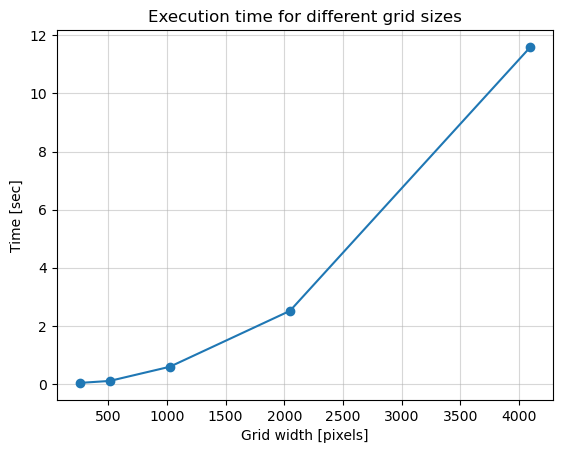

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(grids, times, marker="o")
plt.title("Execution time for different grid sizes")
plt.xlabel("Grid width [pixels]")
plt.ylabel("Time [sec]")
plt.grid(alpha=0.5)
plt.show()

**4. **Predict:** If $1024 \times 1024$ takes $X$ seconds, what should $2048 \times 2048$ take?**
- **(Hint: $4\times$ the pixels — do you get $4\times$ the time?)**

$$1024^2 = 1,048,576$$

$$2048^2 = 4,194,304$$

Assuming that the compute time and grid pixels are linear, then quadrupling the number of pixels results in four times the compute time.

**Questions to consider:**

- **Is the scaling linear in number of pixels?**

It appears so, yes.

- **At what size does the working set exceed your L3 cache?**

```sh
┌──(mikkel@pella)-[~]
└─$ lscpu | grep L3
L3 cache:                                16 MiB (1 instance)
```

Assuming that the memory footprint per pixel is about $C, Z, M = 16B + 16B + 4B = 36B$ (complex128, complex128, int32), then it would be possible to fit:

$$
\frac{16×(1024^2)B}{36B} \approx 466,000 \text{ pixels}
$$

Which is a width of $\sqrt{466,000} \approx 682$ pixels. Anything more than that would exceed the L3 cache.

- **Do you see a “knee” in the scaling curve where performance degrades?**

No, I do not.

****Done?** Commit → share plot with neighbor → try extensions**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 43d25d86dc95ed5b82e7417742e145dce7f7e83b (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Mon Mar 2 20:47:40 2026 +0000

    l02: milestone 4 done
```

### ****Extensions** Memory profiling, region exploration (no time limit)**

#### ****Extension 1: Memory Profiling****

- **Install: `mamba install memory_profiler`**

For sanity check, clean mamba before install.

In [16]:
!mamba clean --all --yes

Collect information..
Cleaning index cache..
Cleaning lock files..
  Package file                                             Size
─────────────────────────────────────────────────────────────────
  /opt/conda/pkgs
─────────────────────────────────────────────────────────────────

  _openmp_mutex-4.5-20_gnu.conda                           29kB
  aws-c-auth-0.9.6-hb9c0fe4_1.conda                       133kB
  aws-c-compression-0.3.2-h8b1a151_0.conda                 22kB
  aws-c-event-stream-0.5.9-h841be55_2.conda                59kB
  aws-c-http-0.10.10-hf621c6d_0.conda                     226kB
  aws-c-io-0.26.1-h3ca20c3_1.conda                        182kB
  aws-c-mqtt-0.14.0-ha25ca29_1.conda                      220kB
  aws-c-s3-0.11.5-h9b5df67_3.conda                        151kB
  aws-checksums-0.2.10-h8b1a151_0.conda                   101kB
  aws-crt-cpp-0.37.3-hb153662_0.conda                     410kB
  aws-sdk-cpp-1.11.747-h133b1ee_1.conda                     4MB
  bzip2-1.0.8-

In [17]:
!mamba install --name nsc2026 memory_profiler -y

[+] 0.0s
[+] 0.1s
conda-forge/linux-64 ━━━━━━╸━━━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
conda-forge/noarch   ━━━━╸━━━━━━━━━━━━━━━╸━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s[+] 0.2s
conda-forge/linux-64 ━━━━━━╸━━━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.1s
conda-forge/noarch   ━━━━╸━━━━━━━━━━━━━━━╸━━   0.0 B /  ??.?MB @  ??.?MB/s  0.1s[+] 0.3s
conda-forge/linux-64 ━━━━━━━━━━━━━━━━━━━━━━━ 188.5kB /  51.4MB @ 704.7kB/s  0.2s
conda-forge/noarch   ━━━━━━━━━━━━━━━━━━━━━━━ 265.2kB /  24.9MB @ 991.6kB/s  0.2s[+] 0.4s
conda-forge/linux-64 ━━━━━━━━━━━━━━━━━━━━━━━ 412.6kB /  51.4MB @   1.3MB/s  0.3s
conda-forge/noarch   ━━━━━━━━━━━━━━━━━━━━━━━ 756.7kB /  24.9MB @   2.4MB/s  0.3s[+] 0.5s
conda-forge/linux-64 ━━━━━━━━━━━━━━━━━━━━━━━   1.3MB /  51.4MB @   2.7MB/s  0.4s
conda-forge/noarch   ╸━━━━━━━━━━━━━━━━━━━━━━   1.9MB /  24.9MB @   4.1MB/s  0.4s[+] 0.6s
conda-forge/linux-64 ━━━━━━━━━━━━━━━━━━━━━━━   1.8MB /  51.4MB @   3.1MB/s  0.5s
conda-forge/noarch   ━╸━━━━━━━━━━━━━━━━━━━━━   2.8M

I have manually added it as a dependency in the `environment.yaml` file.

In [18]:
!cat environment.yaml | grep memory_profiler

  - memory_profiler=0.61.0=pyhcf101f3_1


- **Compare peak memory usage: naive vs NumPy**

Please check the docs on how to run and use https://github.com/pythonprofilers/memory_profiler.

In [19]:
%pycat l02_memory_profiling.py

def main() -> None:
    import matplotlib.pyplot as plt
    from memory_profiler import memory_usage
    from mandelbrot import compute_mandelbrot as naive_python
    from mandelbrot import compute_mandelbrot_numpy as numpy_python

    # Measured in MiB
    naive_mem_usage: list[float] = memory_usage(
        (naive_python, [-2, 1, -1.5, 1.5, 1024, 1024, 100]))
    numpy_mem_usage: list[float] = memory_usage(
        (numpy_python, [-2, 1, -1.5, 1.5, 1024, 1024, 100]))

    plt.plot(naive_mem_usage, label="Naïve")
    plt.plot(numpy_mem_usage, label="Numpy")
    plt.title("Memory usage for 1024x1024 mandelbrot")
    plt.ylabel("Memory usage [MiB]")
    plt.xlabel("Time [sample index]")
    plt.legend()
    plt.grid(alpha=0.5)
    plt.ticklabel_format(style="plain") # prevent scientific notation
    plt.savefig("l01_memory_profile.png")


if __name__ == "__main__":
    main()


In [20]:
!python l02_memory_profiling.py

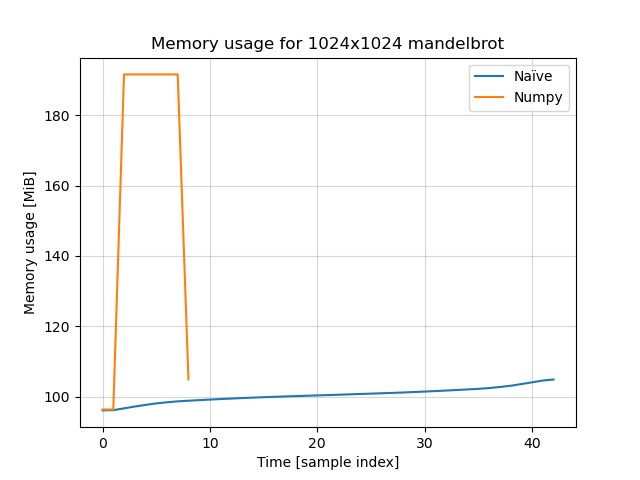

In [21]:
from IPython.display import Image
Image(filename="l02_memory_profile.png")

- **Why does the vectorized version use more memory?**

Numpy operates on *all* the pixels, while the naive only works on those that need it.

We can also see that python's `.append()` in the for loop results in growing memory allocation over time.

#### ****Extension 2: Explore Different Mandelbrot Regions****

- **Zoom into the boundary region (more iterations needed)**

I do not know of "the boundary region", so I have chosen the Seahorse Valley. (See slide number 49 for the parameters)

In [23]:
from mandelbrot import compute_mandelbrot_numpy

image = compute_mandelbrot_numpy(-0.8, -0.7, 0.05, 0.15, 1024, 1024, 500)

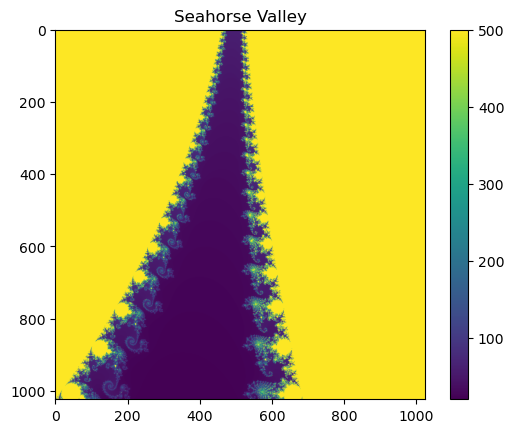

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.title("Seahorse Valley")
plt.imshow(image)
plt.colorbar()
plt.show()

- **Does runtime change? Why? (Hint: the mask)**

Change compared to what? I am unsure what is meant here, so I am comparing the default region/parameters.

In [25]:
# Testing with seahorse valley

# using max_iter = 500 instead of 100
t_default, _ = benchmark(numpy_python,
                         -2, 1, -1.5, 1.5, 1024, 1024, 500)
t_seahorse, _ = benchmark(numpy_python, -0.8, -0.7,
                          0.05, 0.15, 1024, 1024, 500)

if t_default == t_seahorse:
    print("Runtime did NOT change.")
else:
    print("Runtime changed!")

print(f"Default region (median): {t_default:.3f}s")
print(f"Seahorse valley (median): {t_seahorse:.3f}s")

Median: 2.6163s(min=2.6084, max=2.7536)
Median: 6.2525s(min=6.0034, max=6.4473)
Runtime changed!
Default region (median): 2.616s
Seahorse valley (median): 6.253s


From the output, the runtime does change, likely due to the Seahorse Spiral region having more iterations on average per pixel than the default region.

- **Try the famous named regions: **Seahorse Valley**, **Elephant Valley**, or a **Deep Seahorse Spiral****

In [26]:
regions = {
    "standard": {
        "x_min": -2.0,
        "x_max": 1.0,
        "y_min": -1.5,
        "y_max": 1.5,
        "max_iter": 100
    },
    "seahorse_valley": {
        "x_min": -0.8,
        "x_max": -0.7,
        "y_min": 0.05,
        "y_max": 0.15,
        "max_iter": 500
    },
    "elephant_valley": {
        "x_min": 0.175,
        "x_max": 0.375,
        "y_min": -0.1,
        "y_max": 0.1,
        "max_iter": 500
    },
    "deep_seahorse_spiral": {
        "x_min": -0.7487667139,
        "x_max": -0.7487667078,
        "y_min": 0.1236408449,
        "y_max": 0.1236408510,
        "max_iter": 2000
    }
}

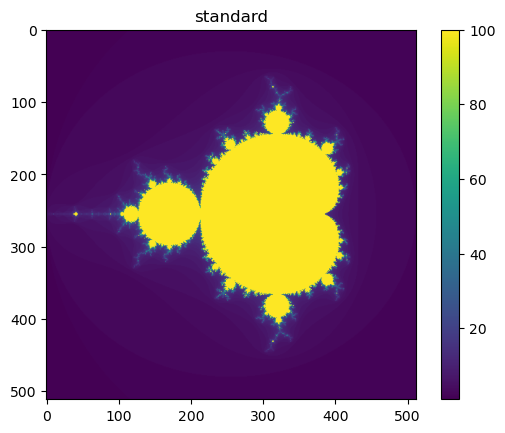

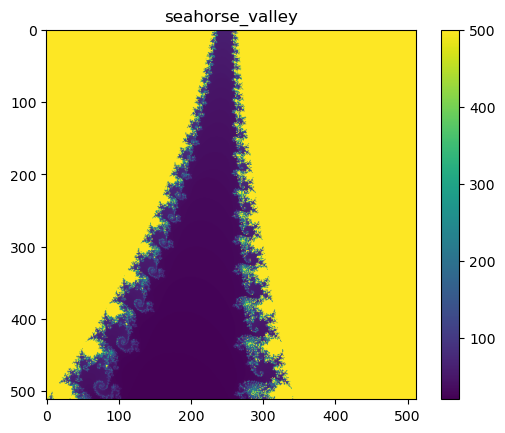

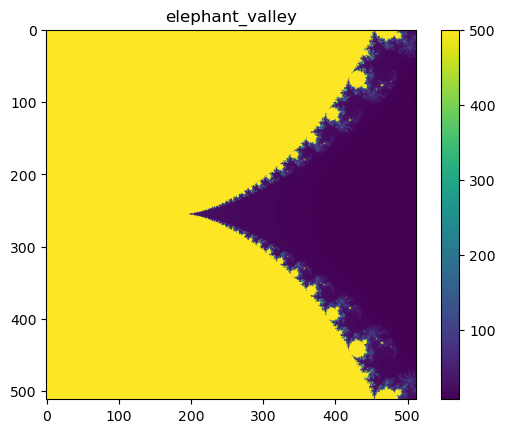

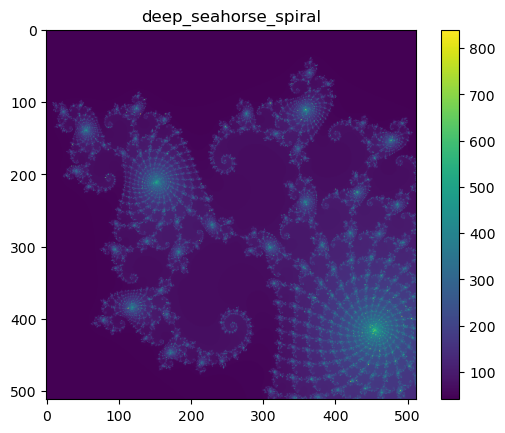

In [27]:
# Default image resolution
width = height = 512

for name, conf in regions.items():

    # Add in the image resolution
    full_conf = {
        **conf,
        "width": width,
        "height": height,
    }

    image = compute_mandelbrot_numpy(**full_conf)

    # plot
    plt.figure()
    plt.imshow(image)
    plt.colorbar()
    plt.title(name)
    plt.show()
    plt.close()

- ***Coordinates for these regions are on the last backup slide***

Noted!

#### ****Extension 3: Help Others!****

- **Teaching deepens your understanding**

Noted, done!